In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def generate_data(n=1000, d=10):
    np.random.seed(42)
    X = np.random.randn(n, d)
    true_w = np.random.randn(d)
    y = X @ true_w + 0.1 * np.random.randn(n)
    return X, y, true_w

X, y, true_w = generate_data()
n, d = X.shape


In [4]:
def f_i_grad(x, i):
    xi = X[i]
    yi = y[i]
    return (xi @ x - yi) * xi


def full_gradient(x):
    grad = np.zeros_like(x)
    for i in range(n):
        grad += f_i_grad(x, i)
    return grad / n


In [5]:
def SAG(epochs=5, lr=0.01):
    x = np.zeros(d)
    y_memory = np.zeros((n, d))  
    g = np.zeros(d)
    visited = np.zeros(n, dtype=bool)

    history = []

    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)

            grad_i = f_i_grad(x, i)

            if not visited[i]:
                g += grad_i / n
                visited[i] = True
            else:
                g += (grad_i - y_memory[i]) / n

            y_memory[i] = grad_i

            x = x - lr * g

        loss = np.mean((X @ x - y) ** 2)
        history.append(loss)

    return x, history


In [7]:
def SGD(epochs=5, lr=0.01):
    x = np.zeros(d)
    history = []

    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)
            grad_i = f_i_grad(x, i)
            x = x - lr * grad_i

        loss = np.mean((X @ x - y) ** 2)
        history.append(loss)

    return x, history

In [8]:
sag_w, sag_hist = SAG(epochs=10, lr=0.01)
sgd_w, sgd_hist = SGD(epochs=10, lr=0.01)


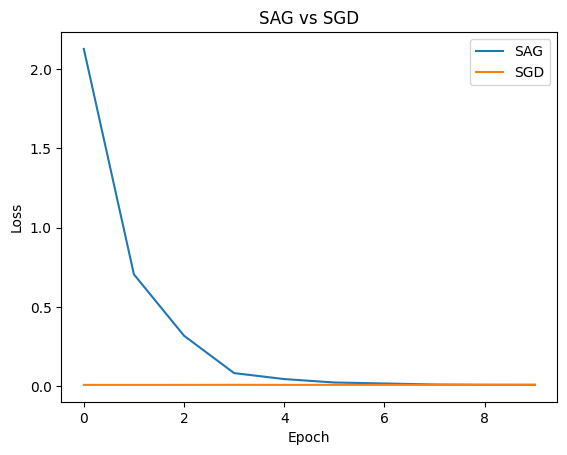

In [9]:
plt.plot(sag_hist, label="SAG")
plt.plot(sgd_hist, label="SGD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("SAG vs SGD")
plt.show()


In [10]:
print("True w:", true_w[:5])
print("SAG w:", sag_w[:5])
print("SGD w:", sgd_w[:5])

True w: [-0.67849473 -0.30549946 -0.59738106  0.11041805  1.19717853]
SAG w: [-0.68466518 -0.30178162 -0.58149773  0.12550402  1.20176516]
SGD w: [-0.66640776 -0.3062474  -0.59536769  0.11895981  1.19891243]
